In [ ]:
!pip install gensim -q

In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec

In [ ]:
corpus = [
    "machine learning is fun",
    "machine learning is powerful",
    "deep learning drives ai",
    "natural language processing is interesting"
]

corpus

['machine learning is fun',
 'machine learning is powerful',
 'deep learning drives ai',
 'natural language processing is interesting']

In [ ]:
vocab = sorted(list(set(" ".join(corpus).split())))
print("Vocabulary:", vocab)

Vocabulary: ['ai', 'deep', 'drives', 'fun', 'interesting', 'is', 'language', 'learning', 'machine', 'natural', 'powerful', 'processing']


In [ ]:
#Bag of words
bow = CountVectorizer()
bow_matrix = bow.fit_transform(corpus)

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=bow.get_feature_names_out()
)

bow_df

,ai,deep,drives,fun,interesting,is,language,learning,machine,natural,powerful,processing
0,0,0,0,1,0,1,0,1,1,0,0,0
1,0,0,0,0,0,1,0,1,1,0,1,0
2,1,1,1,0,0,0,0,1,0,0,0,0
3,0,0,0,0,1,1,1,0,0,1,0,1


In [ ]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(corpus)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df

,ai,deep,drives,fun,interesting,is,language,learning,machine,natural,powerful,processing
0,0.000000,0.000000,0.000000,0.640655,0.00000,0.408922,0.00000,0.408922,0.5051,0.00000,0.000000,0.00000
1,0.000000,0.000000,0.000000,0.000000,0.00000,0.408922,0.00000,0.408922,0.5051,0.00000,0.640655,0.00000
2,0.541736,0.541736,0.541736,0.000000,0.00000,0.000000,0.00000,0.345783,0.0000,0.00000,0.000000,0.00000
3,0.000000,0.000000,0.000000,0.000000,0.47633,0.304035,0.47633,0.000000,0.0000,0.47633,0.000000,0.47633


In [ ]:
tokenized_corpus = [sentence.split() for sentence in corpus]
tokenized_corpus

[['machine', 'learning', 'is', 'fun'],
 ['machine', 'learning', 'is', 'powerful'],
 ['deep', 'learning', 'drives', 'ai'],
 ['natural', 'language', 'processing', 'is', 'interesting']]

In [ ]:
model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=50,
    window=2,
    min_count=1,
    workers=4,
    sg=1  )

In [ ]:
#df.columns -- column names in list
#df.head -- first 5 rows

#model.wv.index_to key-- index vectors
#model.wv. most_similar -- relationship bw words

In [ ]:
model

In [ ]:
for word in model.wv.index_to_key:
    print(f"{word}:\n{model.wv[word]}\n")
  #orange =-1.07
  #is : vector number-- 50 dimensions- unique numbers


  #Toy A Batch number, serial number
  #toy B
  #toy C

is:
[-1.0724545e-03  4.7286271e-04  1.0206699e-02  1.8018546e-02
 -1.8605899e-02 -1.4233618e-02  1.2917745e-02  1.7945977e-02
 -1.0030856e-02 -7.5267432e-03  1.4761009e-02 -3.0669428e-03
 -9.0732267e-03  1.3108104e-02 -9.7203208e-03 -3.6320353e-03
  5.7531595e-03  1.9837476e-03 -1.6570430e-02 -1.8897636e-02
  1.4623532e-02  1.0140524e-02  1.3515387e-02  1.5257311e-03
  1.2701781e-02 -6.8107317e-03 -1.8928028e-03  1.1537147e-02
 -1.5043275e-02 -7.8722071e-03 -1.5023164e-02 -1.8600845e-03
  1.9076237e-02 -1.4638334e-02 -4.6675373e-03 -3.8754821e-03
  1.6154874e-02 -1.1861792e-02  9.0324880e-05 -9.5074680e-03
 -1.9207101e-02  1.0014586e-02 -1.7519170e-02 -8.7836506e-03
 -7.0199967e-05 -5.9236289e-04 -1.5322480e-02  1.9229487e-02
  9.9641159e-03  1.8466286e-02]

learning:
[-0.01631851  0.00899307 -0.00827551  0.00164934  0.01700003 -0.00892582
  0.00903649 -0.01357615 -0.00709814  0.0188001  -0.00315582  0.00064285
 -0.00828262 -0.0153679  -0.00301651  0.0049404  -0.00177635  0.01106914
 -

In [ ]:
model.wv.most_similar("language")

[('deep', 0.2244238406419754),
 ('fun', 0.19776302576065063),
 ('natural', 0.18339458107948303),
 ('processing', 0.10232102125883102),
 ('ai', 0.029594380408525467),
 ('learning', 0.01827714778482914),
 ('is', 0.012442175298929214),
 ('machine', -0.02784133516252041),
 ('powerful', -0.08306729048490524),
 ('drives', -0.10186850279569626)]

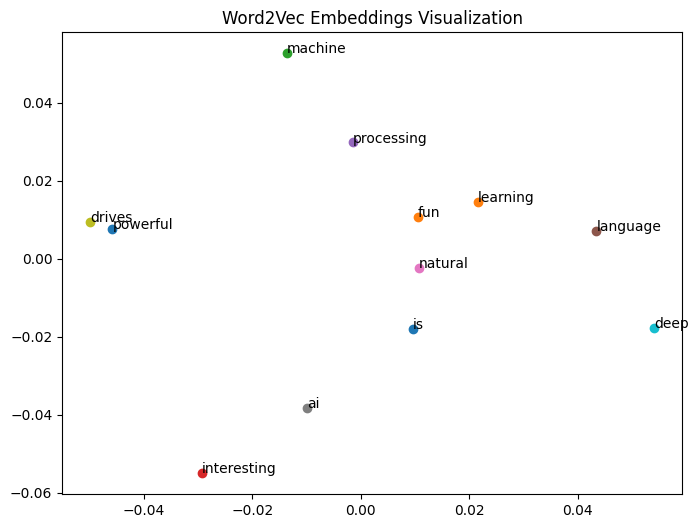

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

words = list(model.wv.index_to_key)
vectors = np.array([model.wv[word] for word in words])

pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))
for i, word in enumerate(words):
    plt.scatter(reduced[i, 0], reduced[i, 1])
    plt.text(reduced[i, 0], reduced[i, 1], word)

plt.title("Word2Vec Embeddings Visualization")
plt.show()